In [149]:

import pandas as pd
import seaborn
import seaborn as sns
import xgboost
from catboost import CatBoostRegressor
from sklearn.compose import TransformedTargetRegressor

from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PolynomialFeatures,PowerTransformer
from sklearn.model_selection import train_test_split,cross_val_score,KFold
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt
import lightgbm
from sklearn.linear_model import LinearRegression,Ridge,Lasso
import optuna
from sklearn.model_selection import cross_val_score,cross_validate,cross_val_predict
from sklearn.ensemble import IsolationForest
from statsmodels.api import OLS
import  statsmodels.api as sm
from sklearn.impute import SimpleImputer


In [ ]:

def load_data():
    X = pd.read_csv("StudentPerformanceFactors.csv")
    #X.drop(columns=["Gender","Sleep_Hours","School_Type"],inplace=True)
    #X=X.dropna().reset_index(drop=True)


    #
    #X = X[X["Exam_Score"] < 78]
    columns = ['Exam_Score']
    outlier_percentage = {}

    for column in columns:
        column_data = X[column]

        Q1 = np.percentile(column_data, 25)
        Q3 = np.percentile(column_data, 75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = column_data[(column_data < lower) | (column_data > upper)]
        outlier_percentage[column] = len(outliers) / len(column_data) * 100
        X = X[(X["Exam_Score"] >= lower) & (X["Exam_Score"] <= upper)]

    y = X["Exam_Score"]

    X.drop(columns=["Exam_Score"], inplace=True)


    return X,y
X,y = load_data()
X


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female



## ALKAA

R2 Score: 0.9899433142969226
R2 OLS: 0.9899433142969225


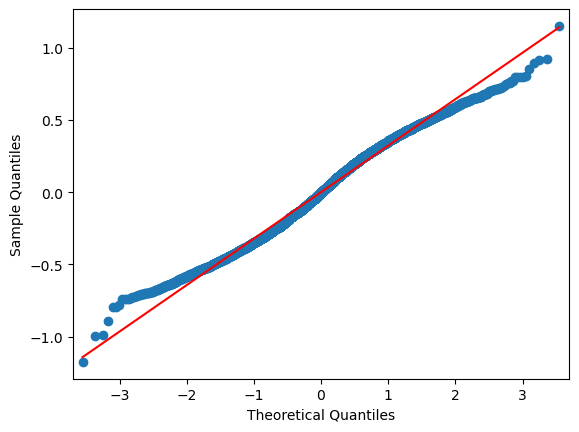

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Exam_Score   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 1.746e+04
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:31:01   Log-Likelihood:                -1479.4
No. Observations:                5202   AIC:                             3021.
Df Residuals:                    5171   BIC:                             3224.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    68.1203      0.031   2175.414      0.000      68.059      68.182
Hours_Studied                             1.7566      0.004    391.500      0.000       1.748       1.765
Attendance                                2.3000      0.005    510.938      0.000       2.291       2.309
Sleep_Hours                               0.0238      0.004      5.317      0.000       0.015       0.033
Previous_Scores                           0.7091      0.004    158.059      0.000       0.700       0.718
Tutoring_Sessions                         0.6095      0.004    136.119      0.000       0.601       0.618
Physical_Activity                         0.2401      0.004     53.715      0.000       0.231       0.249
Parental_Involvement_Low                 -1.9889      0.013   -152.406      0.000      -2.015      -1.963
Parental_Involvement_Medium              -1.0068      0.010    -96.269      0.000      -1.027      -0.986
Access_to_Resources_Low                  -1.9976      0.013   -154.687      0.000      -2.023      -1.972
Access_to_Resources_Medium               -0.9835      0.010    -94.868      0.000      -1.004      -0.963
Extracurricular_Activities_Yes            0.5051      0.009     55.354      0.000       0.487       0.523
Motivation_Level_Low                     -1.0018      0.013    -76.743      0.000      -1.027      -0.976
Motivation_Level_Medium                  -0.4910      0.012    -41.221      0.000      -0.514      -0.468
Internet_Access_Yes                       0.9976      0.017     58.418      0.000       0.964       1.031
Family_Income_Low                        -0.9907      0.012    -79.986      0.000      -1.015      -0.966
Family_Income_Medium                     -0.4874      0.012    -39.423      0.000      -0.512      -0.463
Teacher_Quality_Low                      -1.0039      0.016    -61.004      0.000      -1.036      -0.972
Teacher_Quality_Medium                   -0.5072      0.010    -50.211      0.000      -0.527      -0.487
Teacher_Quality_nan                      -0.3443      0.043     -7.954      0.000      -0.429      -0.259
School_Type_Public                       -0.0002      0.010     -0.024      0.981      -0.019       0.019
Peer_Influence_Neutral                    0.4861      0.012     40.017      0.000       0.462       0.510
Peer_Influence_Positive                   0.9992      0.012     82.567      0.000       0.976       1.023
Learning_Disabilities_Yes                -1.0109      0.015    -68.861      0.000      -1.040      -0.982
Parental_Education_Level_High School     -0.4971      0.010    -47.775      0.000      -0.518      -0.477
Parental_Education_Level_Postgraduate     0.5198      0.013     40.154      0.000       0.494       0.545
Parental_

In [418]:
import shap
X,y=load_data()



categorical_columns = X.select_dtypes(include="object").columns.tolist()
numeric = X.select_dtypes(exclude="object").columns.tolist()
encoder = OneHotEncoder(sparse_output=False,drop='first')
imputer = SimpleImputer(strategy='most_frequent')
columns = X.columns.tolist()
#X = imputer.fit_transform(X)
X = pd.DataFrame(X,columns=columns)


encoded = encoder.fit_transform(X[categorical_columns])
X.drop(columns=categorical_columns,inplace=True)
encoded_names = encoder.get_feature_names_out()
X = pd.concat(
    [X, pd.DataFrame(encoded, columns=encoded_names, index=X.index)],
    axis=1
)
scaler = StandardScaler()
X[numeric] = scaler.fit_transform(X[numeric])

X.columns = X.columns.astype(str)
X,X_test,y,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


lm = LinearRegression()

lm.fit(X,y)
preds = lm.predict(X_test)

r2 = r2_score(y_test,preds)
print(f'R2 Score: {r2}')
coefs = pd.DataFrame({"feature": X.columns, "coef": lm.coef_})

#explainer = shap.LinearExplainer(lm, X)
#shap_values = explainer(X)
#shap.summary_plot(shap_values)

coefs.sort_values(by="coef",ascending=False,inplace=True)
coefs
X_train = sm.add_constant(X)
X_test = sm.add_constant(X_test)
ols =OLS(y,X_train)
ols_model = ols.fit()
preds_ols = ols_model.predict(X_test)
r2_ols =r2_score(y_test,preds_ols)
print(f'R2 OLS: {r2_ols}')
ols_model.summary()

res = ols_model.resid # residuals
#Q-Q kuvaaja
sm.qqplot(res,line='s')

pd.DataFrame(coefs)
resid_ols = y_test - preds_ols

#sns.scatterplot(x=preds_ols,y=resid_ols)

#plt.ylim((-2,2))
#
#plt.xlabel("Ennustettu arvo")
#plt.ylabel("Jäännös")
#plt.axhline(y=0, color='r', linestyle='-')
plt.show()
ols_model.summary()


Text(0, 0.5, 'Exam Score')

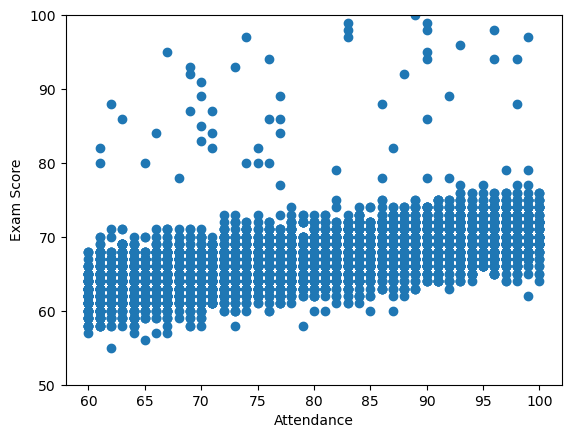

In [274]:
X,y = load_data()
plt.scatter(X["Attendance"],y)
plt.ylim([50,100])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")

Text(0.5, 1.0, 'Poikkeavat havainnot poistettu')

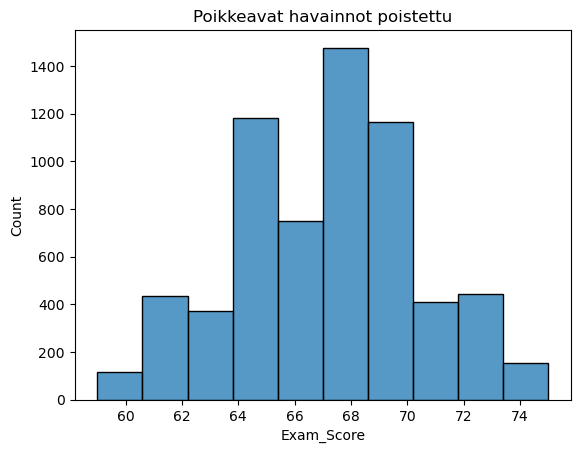

In [329]:
sns.histplot(y,bins=10)

plt.title("Poikkeavat havainnot poistettu")


## LOPPUU

[0]	validation_0-rmse:3.22987
[100]	validation_0-rmse:1.45781
[200]	validation_0-rmse:1.05291
[300]	validation_0-rmse:0.85881
[400]	validation_0-rmse:0.75258
[500]	validation_0-rmse:0.69178
[600]	validation_0-rmse:0.65595
[700]	validation_0-rmse:0.63479
[800]	validation_0-rmse:0.62059
[900]	validation_0-rmse:0.61106
[1000]	validation_0-rmse:0.60450
[1100]	validation_0-rmse:0.59945
[1200]	validation_0-rmse:0.59485
[1300]	validation_0-rmse:0.59157
[1400]	validation_0-rmse:0.58909
[1499]	validation_0-rmse:0.58671
R2 full 0.9689467549324036 


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

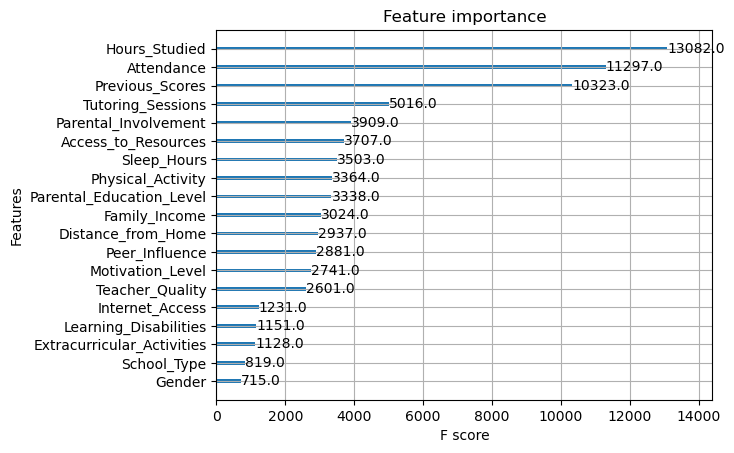

In [423]:
# X,y = load_data()
# #y=np.log(y)
# categorical_columns = X.select_dtypes(include="object").columns.tolist()
# X[categorical_columns] = X[categorical_columns].astype("category")
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
# X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
# model = XGBRegressor(n_estimators=1500,learning_rate=0.02,enable_categorical=True,reg_lambda=10,random_state=42,early_stopping_rounds = 50)
# model.fit(X_train,y_train,eval_set=[(X_validation,y_validation)],verbose=100)
# preds = model.predict(X_test)

# resid = preds-y_test
# r2 = r2_score(y_test,preds)


# print(f'R2 full {r2} ')

# resid = y_test-preds
# xgboost.plot_importance(model)
# #sns.scatterplot(x=preds,y=y_test,hue  =resid)

## CAT

In [421]:
X,y = load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].fillna("NaN")
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
model_cat =CatBoostRegressor(use_best_model=True,early_stopping_rounds=50)
model_cat.fit(X_train,y_train,cat_features=categorical_columns,eval_set=[(X_validation,y_validation)],verbose=100)
preds = model_cat.predict(X_test)
r2_test=r2_score(y_test,preds)
preds_full =model_cat.predict(X)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')


Learning rate set to 0.0646
0:	learn: 0.0466317	test: 0.0469212	best: 0.0469212 (0)	total: 199ms	remaining: 3m 18s
100:	learn: 0.0105483	test: 0.0110658	best: 0.0110658 (100)	total: 2.41s	remaining: 21.5s
200:	learn: 0.0066857	test: 0.0070138	best: 0.0070138 (200)	total: 4.99s	remaining: 19.8s
300:	learn: 0.0054695	test: 0.0060514	best: 0.0060514 (300)	total: 8.02s	remaining: 18.6s
400:	learn: 0.0049712	test: 0.0057863	best: 0.0057863 (400)	total: 10.7s	remaining: 15.9s
500:	learn: 0.0046679	test: 0.0056279	best: 0.0056278 (498)	total: 13.3s	remaining: 13.3s
600:	learn: 0.0044455	test: 0.0055485	best: 0.0055485 (600)	total: 16.3s	remaining: 10.8s
700:	learn: 0.0042754	test: 0.0054873	best: 0.0054869 (699)	total: 19.5s	remaining: 8.33s
800:	learn: 0.0041277	test: 0.0054422	best: 0.0054422 (800)	total: 22.4s	remaining: 5.57s
900:	learn: 0.0039877	test: 0.0054147	best: 0.0054147 (900)	total: 25.3s	remaining: 2.77s
999:	learn: 0.0038635	test: 0.0053964	best: 0.0053964 (999)	total: 28.1s	re

## LGBM

In [ ]:

X,y =  load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].astype("category")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
params = {'learning_rate': 0.0970688720107848, 'num_leaves': 20, 'feature_fraction': 0.7206082609076269, 'max_depth': 4}
model = lightgbm.LGBMRegressor(**params,random_state=42,early_stopping_rounds = 50,n_estimators=5000)
model.fit(X_train,y_train,categorical_feature=categorical_columns,eval_set=[(X_validation,y_validation)])
preds = model.predict(X_test)
preds_full = model.predict(X)
r2 = r2_score(y_test,preds)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')
